In [58]:
import numpy as np
import matplotlib.pyplot as plt

In [59]:
# Plots 2D validation of Modes given by certain cases
def plot2D(ProjectName, mode_id, nx, ny, mode_type="POD"):
    """
    Plots 2D visualization of a mode (POD or DMD), with cylinder overlay built in.

    Parameters:
    - ProjectName (str): Base name for the mode file
    - mode_id (int): Mode index (1-based)
    - nx, ny (int): Grid dimensions (X × Y)
    - mode_type (str): Either 'POD' or 'DMD'
    """

    # Define cylinder overlay parameters (from MATLAB center (49, 99), radius 25)
    theta = np.linspace(0, 2 * np.pi, 100, endpoint=False)
    cx, cy, r = 48, 98, 25  # MATLAB to Python index shift
    x_cyl = cx + r * np.sin(theta)
    y_cyl = cy + r * np.cos(theta)

    if mode_type.upper() == "POD":
        filename = f"{ProjectName}_Mode_{mode_id}.txt"
        mode = np.loadtxt(filename)
        mode_reshaped = mode.reshape(ny, nx).T

        plt.imshow(mode_reshaped, cmap='viridis', origin='lower', aspect='equal')
        plt.colorbar(label=f"{ProjectName} POD Mode {mode_id}")
        plt.title(f"POD Mode {mode_id}")

        # Draw cylinder overlay
        plt.fill(x_cyl, y_cyl, color=(0.3, 0.3, 0.3), zorder=3)
        plt.plot(x_cyl, y_cyl, color='k', linewidth=1.2, zorder=4)

        plt.show()
        return mode_reshaped

    elif mode_type.upper() == "DMD":
        filename = f"{ProjectName}_dmdMode_{mode_id}.txt"
        mode = np.loadtxt(filename, dtype=complex)
        mode_real = mode.real.reshape(ny, nx).T
        mode_imag = mode.imag.reshape(ny, nx).T

        fig, axs = plt.subplots(1, 2, figsize=(12, 5))

        im1 = axs[0].imshow(mode_real, cmap='coolwarm', origin='lower', aspect='equal')
        axs[0].set_title(f"DMD Mode {mode_id} (Real Part)")
        axs[0].fill(x_cyl, y_cyl, color=(0.3, 0.3, 0.3), zorder=3)
        axs[0].plot(x_cyl, y_cyl, color='k', linewidth=1.2, zorder=4)
        plt.colorbar(im1, ax=axs[0])

        im2 = axs[1].imshow(mode_imag, cmap='coolwarm', origin='lower', aspect='equal')
        axs[1].set_title(f"DMD Mode {mode_id} (Imag Part)")
        axs[1].fill(x_cyl, y_cyl, color=(0.3, 0.3, 0.3), zorder=3)
        axs[1].plot(x_cyl, y_cyl, color='k', linewidth=1.2, zorder=4)
        plt.colorbar(im2, ax=axs[1])

        plt.suptitle(f"{ProjectName} DMD Mode {mode_id}")
        plt.tight_layout()
        plt.show()
        return mode_real, mode_imag

    else:
        raise ValueError("mode_type must be either 'POD' or 'DMD'.")


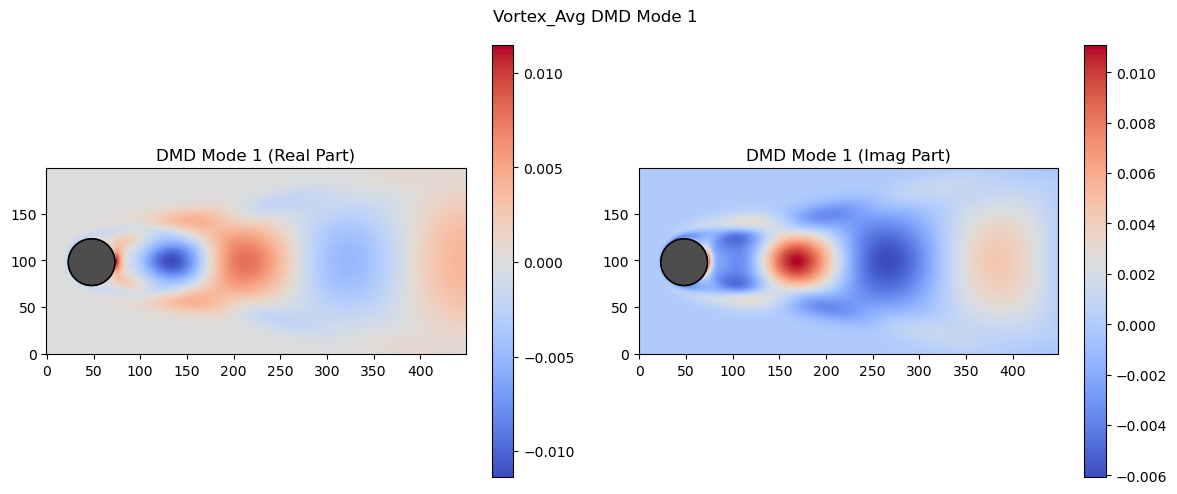

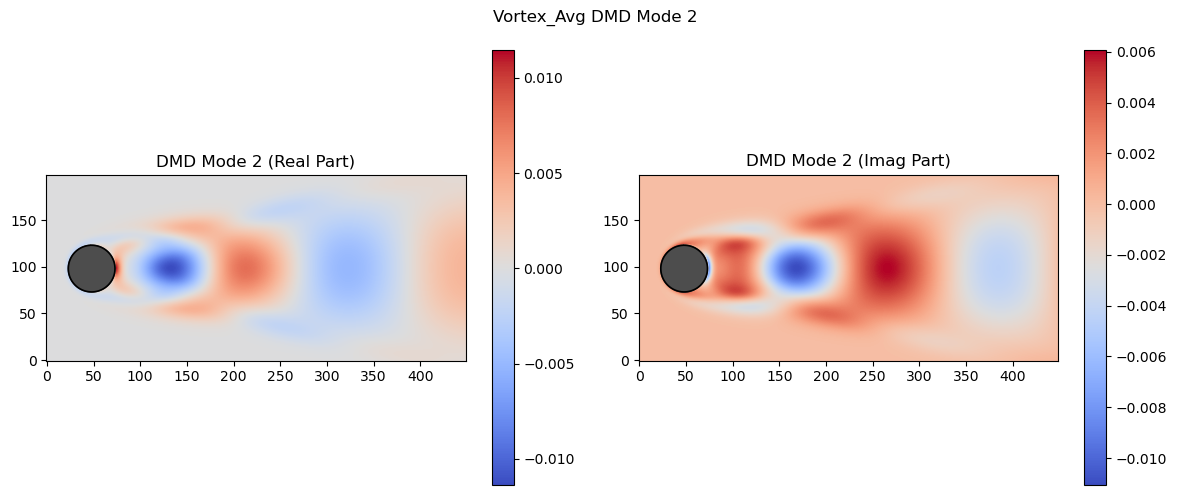

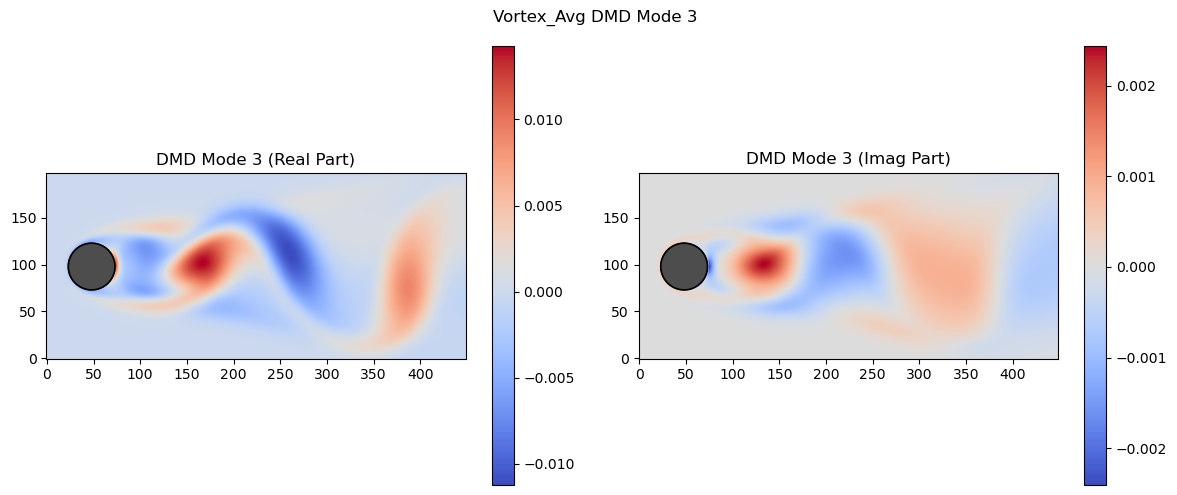

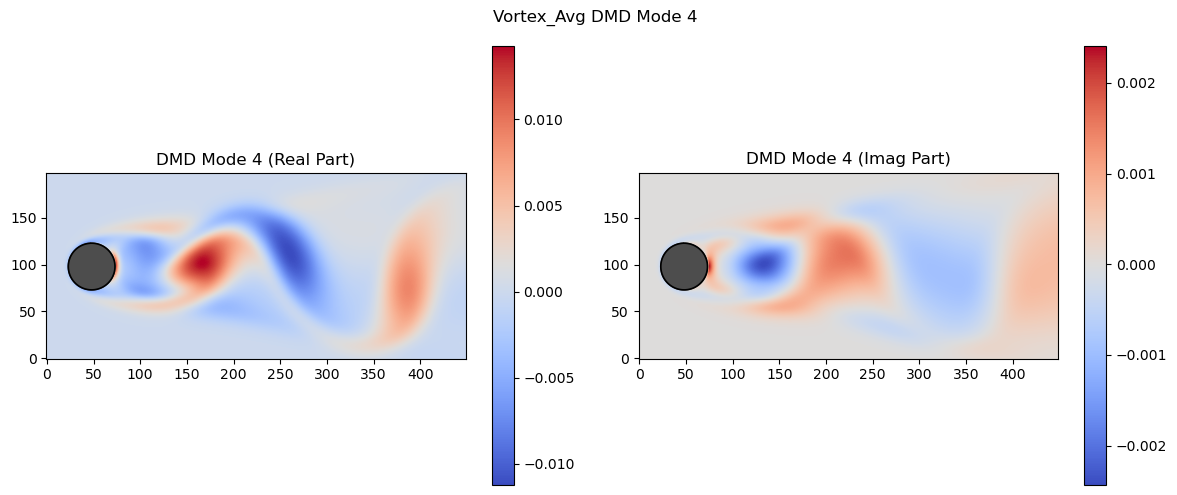

In [60]:
if __name__ == "__main__":
    for i in range(4):
        mode_reshaped = plot2D('Vortex_Avg', i+1, 199, 449, "DMD")
        
